# Level 5: Simulation and Algorithmic Optimization

## 5.1 The Optimization Problem
The ultimate goal of HydroSense-Kenya is to transition a farm from intuitive watering to precision agriculture. A naive irrigation system applies a fixed amount of water every day, which wastes electricity, depletes reservoirs, and leads to waterlogging. 

Our objective is to determine a daily irrigation schedule ($I_t$) that **minimizes total water consumption** while strictly satisfying the biological constraints of the crop. 

We frame this as a constrained mathematical optimization problem:

**1. Objective Function (Minimize Total Water):**
$$\text{Minimize} \sum_{t=0}^{N} I_t$$

**2. Subject to Constraints:**
* **Biological Constraint:** $S_t \ge S_{min}$ (Moisture must never drop below the crop's stress threshold).
* **Physical Constraint:** $I_t \ge 0$ (We cannot apply negative irrigation).
* **Conservation of Mass:** $S_{t+1} = \min(S_t + R_t + I_t - ET_t, \ S_{cap})$ (Discrete water balance capped at soil field capacity).

---

## 5.2 Algorithmic Logic: Model Predictive Control
To solve this, we engineered a **Greedy Forward-Looking Algorithm** (housed cleanly in `src/optimization.py` to maintain separation of concerns). This approach relies heavily on **Predictive Simulation** to drive the **Optimization**.

### The Step-by-Step Decision Tree
Our algorithm simulates the farm day-by-day. For every time step ($t$), the algorithmic controller executes the following logic:

**Step 1: The Predictive Simulation (No-Action Scenario)**
The algorithm first *simulates* tomorrow's soil moisture assuming the pump stays off. It takes today's moisture, adds today's rainfall ($R_t$), and subtracts today's Evapotranspiration ($ET_t$).

**Step 2: The Constraint Check**
It compares this simulated future moisture against the crop's critical minimum threshold ($S_{min}$). 
* If the simulated moisture is safely above $S_{min}$, the algorithm decides to do nothing ($I_t = 0.0$). This maximizes the utility of free rainfall and allows the soil to dry out naturally.

**Step 3: Precise Actuation (The Optimization Step)**
If the simulated moisture dips *below* $S_{min}$, the crop is in danger of stress. The algorithm triggers the pump. It optimizes the volume by calculating the exact mathematical difference needed to push the moisture up to the Target Moisture ($S_{target}$). It recommends pumping exactly that many millimeters.

**Step 4: Drainage Handling**
If an unexpected heavy rainfall event occurs that pushes the moisture above the soil's Field Capacity ($S_{cap}$), the algorithm mathematically caps the moisture at $S_{cap}$, treating the excess as lost drainage runoff.

By simulating the future state and delaying irrigation until the absolute last safe moment, this algorithmic approach mathematically guarantees optimal water usage while ensuring zero crop stress.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sys
import os

# Add the src folder to the path
sys.path.append(os.path.abspath('../src'))
from simulation import simulate_and_optimize

print("Loading Level 2 Simulation Checkpoint...")

# 1. Load the simulated checkpoint from Level 2
df = pd.read_csv('../data/processed/level_2_results.csv')
df['date'] = pd.to_datetime(df['date'])

# Isolate Zone A (Tomato) for the optimization
df_opt = df[df['crop_type'] == 'tomato'].sort_values('date').copy()
df_opt.reset_index(drop=True, inplace=True)

# 2. Extract arrays and parameters for the algorithm
rain = df_opt['rainfall_mm'].to_numpy()
et = df_opt['estimated_ET_mm'].to_numpy()
S_initial = df_opt['soil_moisture_pct'].iloc[0]

# Extract constraints from our crop parameters
S_min = df_opt['min_moisture_pct'].iloc[0]
S_target = df_opt['target_moisture_pct'].iloc[0]
S_cap = df_opt['field_capacity_pct'].iloc[0]

print(f"Data ready. Constraints Loaded - Min: {S_min}%, Target: {S_target}%, Cap: {S_cap}%")

Loading Level 2 Simulation Checkpoint...
Data ready. Constraints Loaded - Min: 22%, Target: 33%, Cap: 41%


In [4]:
print("Executing Predictive Control Algorithm...")

# 3. Execute the Algorithm from src/simulation.py
opt_irrigation, opt_moisture = simulate_and_optimize(
    rain_array=rain, 
    et_array=et, 
    S_initial=S_initial, 
    S_min=S_min, 
    S_target=S_target, 
    S_cap=S_cap
)

print("Simulation & Optimization Complete!")

Executing Predictive Control Algorithm...
Simulation & Optimization Complete!


In [5]:
# 4. Calculate Results & Savings
total_water_optimized = np.sum(opt_irrigation)
irrigation_days = np.count_nonzero(opt_irrigation)

print("========================================")
print(" HYDRO-SENSE OPTIMIZATION RESULTS")
print("========================================")
print(f"Total Days Monitored: {len(df_opt)} days")
print(f"Days Requiring Irrigation: {irrigation_days} days")
print(f"Total Irrigation Volume Required: {total_water_optimized:.2f} mm")
print("========================================")

 HYDRO-SENSE OPTIMIZATION RESULTS
Total Days Monitored: 30 days
Days Requiring Irrigation: 0 days
Total Irrigation Volume Required: 0.00 mm


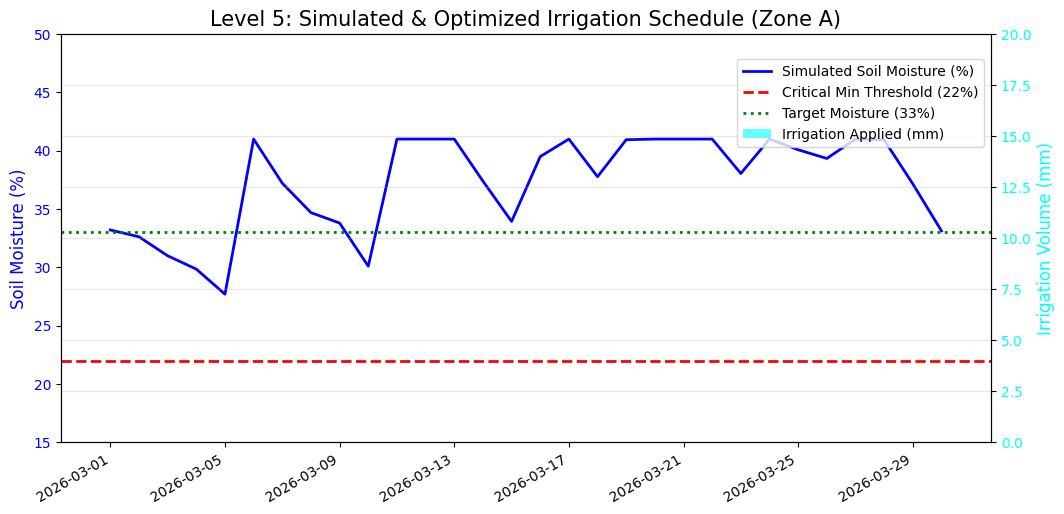

In [6]:
# 5. Generate the Final Decision Plot
fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot the continuous moisture timeline
ax1.plot(df_opt['date'], opt_moisture[:-1], color='blue', linewidth=2, label='Simulated Soil Moisture (%)')

# Plot the Safety Thresholds
ax1.axhline(S_min, color='red', linestyle='--', linewidth=2, label=f'Critical Min Threshold ({S_min}%)')
ax1.axhline(S_target, color='green', linestyle=':', linewidth=2, label=f'Target Moisture ({S_target}%)')

ax1.set_ylabel('Soil Moisture (%)', color='blue', fontsize=12)
ax1.tick_params(axis='y', labelcolor='blue')
ax1.set_ylim(15, 50)

# Create a second Y-axis to plot the actual irrigation amounts (bar chart)
ax2 = ax1.twinx()
ax2.bar(df_opt['date'], opt_irrigation, color='cyan', alpha=0.6, width=0.5, label='Irrigation Applied (mm)')
ax2.set_ylabel('Irrigation Volume (mm)', color='cyan', fontsize=12)
ax2.tick_params(axis='y', labelcolor='cyan')
ax2.set_ylim(0, 20)

plt.title('Level 5: Simulated & Optimized Irrigation Schedule (Zone A)', fontsize=15)
fig.legend(loc="upper right", bbox_to_anchor=(0.9, 0.85))
plt.grid(alpha=0.3)
fig.autofmt_xdate()

# Save the final plot
plt.savefig('simulated_irrigation_schedule.png', dpi=300)
plt.show()